# Prophet

In [310]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [311]:
!ls ./drive/MyDrive/data/c*.csv

./drive/MyDrive/data/ch11_potato.csv
./drive/MyDrive/data/ch2_scores_em.csv
./drive/MyDrive/data/ch4_scores400.csv
./drive/MyDrive/data/co2-ppm-daily_csv.csv


In [312]:
df = pd.read_csv('./drive/MyDrive/data/co2-ppm-daily_csv.csv') # 온난화 관련 기후 자료

In [313]:
df.head()

,date,value
0,1958-03-30,316.16
1,1958-03-31,316.40
2,1958-04-02,317.67
3,1958-04-03,317.76
4,1958-04-04,317.09


In [314]:
df['date'] = pd.to_datetime(df['date'])

In [315]:
df.columns = ['ds', 'y']

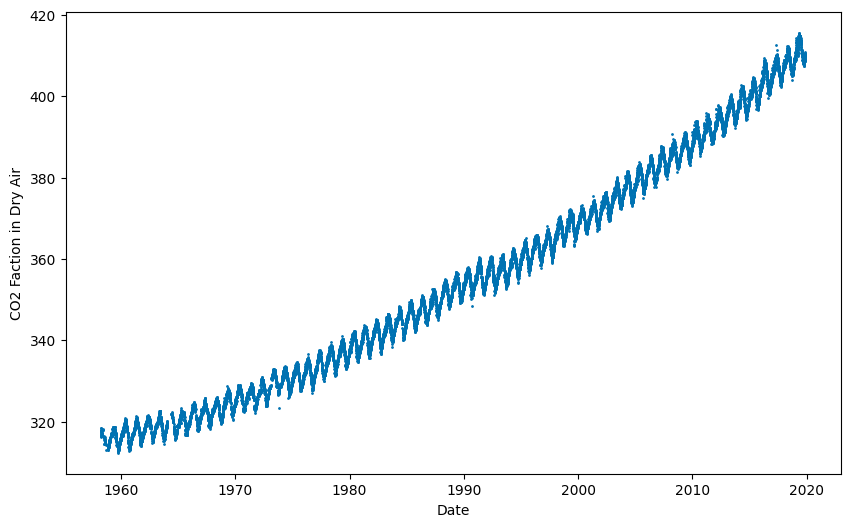

In [316]:
plt.figure(figsize=(10, 6))
plt.scatter(pd.to_datetime(df['ds']), df['y'], s=1, c='#0072B2')
plt.xlabel('Date')
plt.ylabel('CO2 Faction in Dry Air')
plt.show()

In [317]:
model = Prophet()
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [318]:
future = model.make_future_dataframe(periods=365*10) # 1의 데이터를 만들어놓는다?
forecast = model.predict(future)

In [319]:
forecast.tail() # yhat값이 최종적인 예측값

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
23032,2029-11-16,435.104535,423.233231,442.760308,425.491499,444.803730,-2.007822,-2.007822,-2.007822,0.003807,0.003807,0.003807,-2.011629,-2.011629,-2.011629,0.0,0.0,0.0,433.096713
23033,2029-11-17,435.110939,423.568296,442.878610,425.492686,444.815034,-1.969396,-1.969396,-1.969396,-0.004586,-0.004586,-0.004586,-1.964811,-1.964811,-1.964811,0.0,0.0,0.0,433.141542
23034,2029-11-18,435.117342,423.410321,442.798886,425.493874,444.826338,-1.915139,-1.915139,-1.915139,0.003257,0.003257,0.003257,-1.918397,-1.918397,-1.918397,0.0,0.0,0.0,433.202203
23035,2029-11-19,435.123746,423.519157,442.926181,425.495062,444.837311,-1.883292,-1.883292,-1.883292,-0.010815,-0.010815,-0.010815,-1.872477,-1.872477,-1.872477,0.0,0.0,0.0,433.240454
23036,2029-11-20,435.130150,423.608568,442.980023,425.496250,444.846116,-1.822766,-1.822766,-1.822766,0.004365,0.004365,0.004365,-1.827131,-1.827131,-1.827131,0.0,0.0,0.0,433.307384


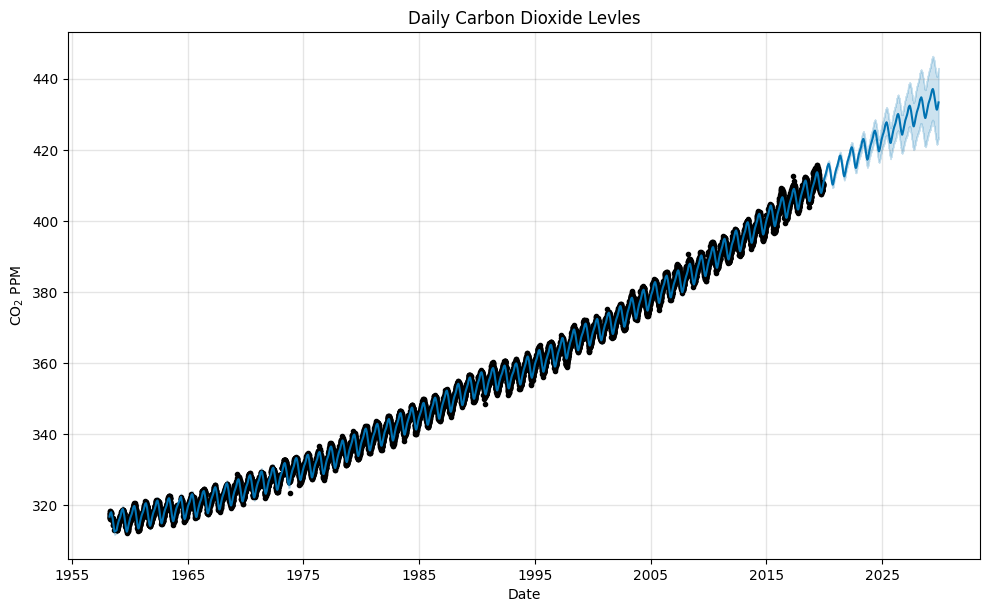

In [320]:
fig = model.plot(forecast, xlabel='Date', ylabel=r'CO$_2$ PPM')
plt.title('Daily Carbon Dioxide Levles')
plt.show()

In [321]:
forecast.head(3).T

,0,1,2
ds,1958-03-30 00:00:00,1958-03-31 00:00:00,1958-04-02 00:00:00
trend,314.876619,314.879021,314.883824
yhat_lower,316.049065,316.06143,316.123457
yhat_upper,317.711443,317.740469,317.872747
trend_lower,314.876619,314.879021,314.883824
trend_upper,314.876619,314.879021,314.883824
additive_terms,1.985677,2.01566,2.118858
additive_terms_lower,1.985677,2.01566,2.118858
additive_terms_upper,1.985677,2.01566,2.118858
weekly,0.003257,-0.010815,0.003454


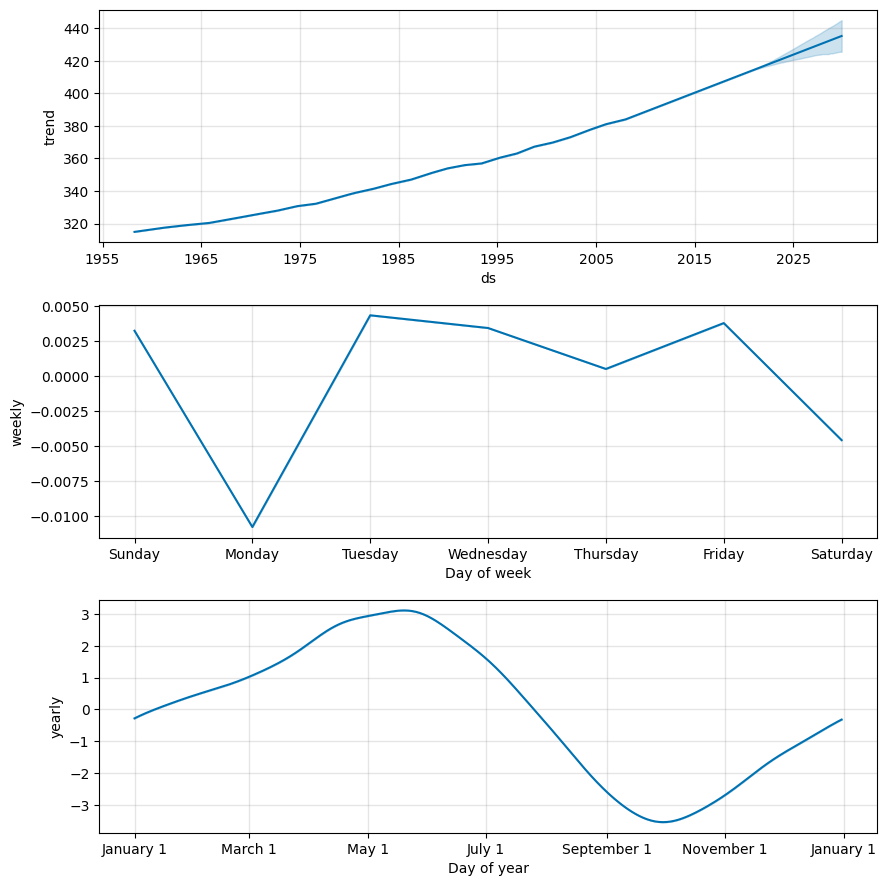

In [322]:
fig2 = model.plot_components(forecast)
plt.show()

In [323]:
model_95 = Prophet(interval_width=0.95)
model_95.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [324]:
future_95 = model_95.make_future_dataframe(periods=365*10)
forecast_95 = model_95.predict(future_95)

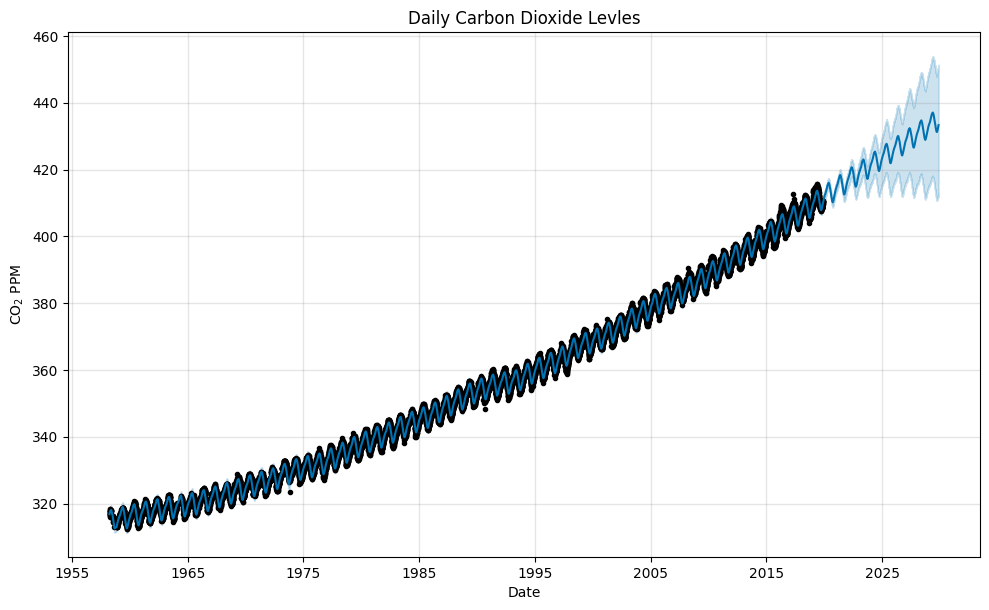

In [325]:
fig_95 = model_95.plot(forecast_95, xlabel='Date', ylabel=r'CO$_2$ PPM')
plt.title('Daily Carbon Dioxide Levles')
plt.show()

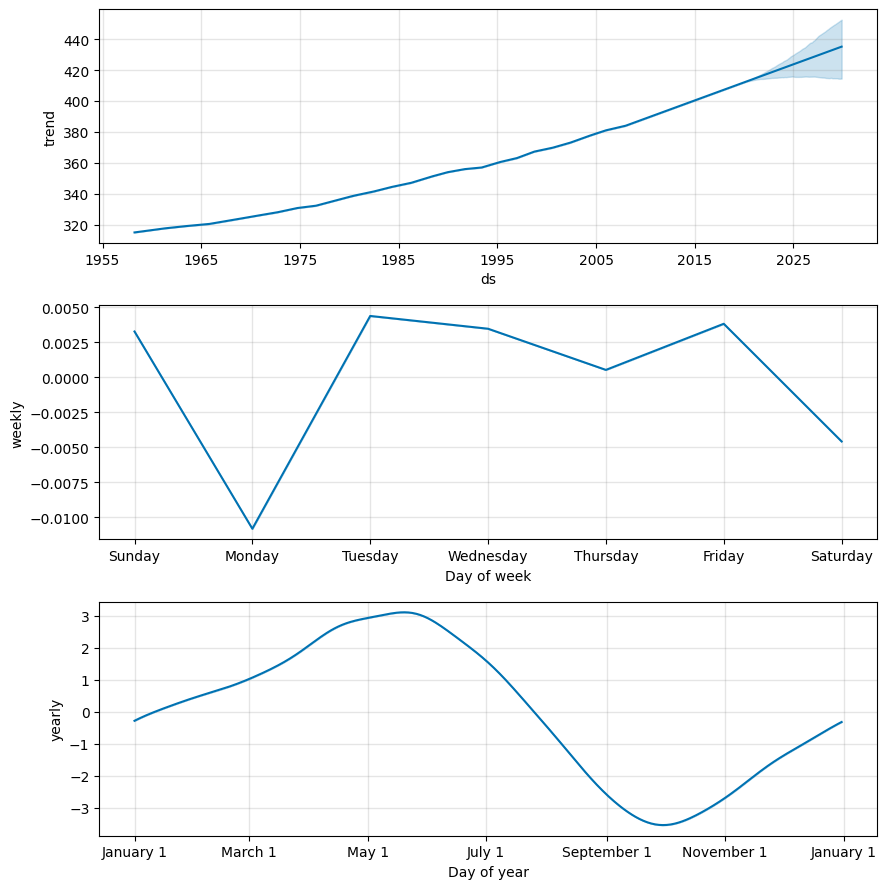

In [326]:
fig_components_95 = model_95.plot_components(forecast_95)
plt.show()

$$
y(t) = g(t) + s(t) + h(t) + \epsilon_t
$$

g(t) = 성장 요소, 일반 추세로 비주기성을 갖는다.

s(t) = 계절성 요소, 여러개의 주기 함수를 합하여 만든다.

h(t) = 공휴의 요소, 단발성 이벤트도 추가 가능

e_t = 오차항

# Prophet 작동원리
1. g(t)
- 선형 추세
- 로지스틱 함수 형태

- 선형추세
$$\\ \ \\
g(t) = (k + a(t)^T \delta) t + (m + a(t)^T \gamma)
\\ \ \\
a_j(t)=
\begin{cases}
1,  & if \  t \ \ge \ s_j \\
0,  & otherwise
\end{cases}
$$

$$\gamma_j = -s_j \delta_j$$

- 로지스틱 함수 형태
$$
K = \frac{1}{1+e^{-x}}
$$

$$
g(t) = \frac{C}{1+e^{-k(t-m)}}
\\ \ \\
\\ \downarrow \\
\\ \ \\
g(t) = \frac{C(t)}{1+e^{-(k+a(t)^T \delta )(t-(m+a(t)^T \gamma))}}
\\ \ \\
\gamma_j = (s_j - m - \sum_{l < j} \gamma_l) \biggl(1-\frac{k+\sum_{l < j}{\delta_l}}{k+\sum_{l \le j}{\delta_l}} \biggr)
$$

In [327]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

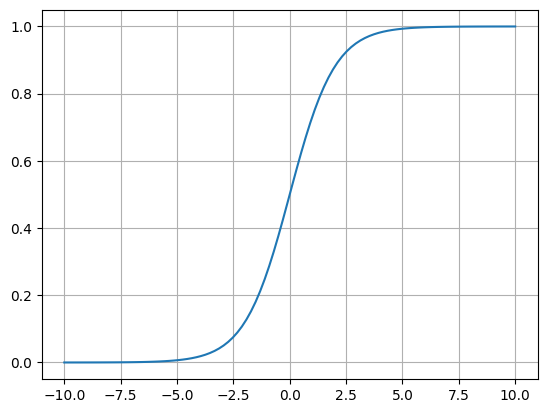

In [328]:
xs = np.linspace(-10, 10, 100)
ys = sigmoid(xs)
plt.plot(xs, ys)
plt.grid()
plt.show()

In [329]:
import random
random.seed(42)

In [330]:
# 변경점을 시각화 할때 사용하는 함수
from prophet.plot import add_changepoints_to_plot

In [331]:
x = pd.to_datetime(pd.date_range('2015-01', '2024-02', freq='MS').strftime('%Y-%m-%d').tolist())

In [332]:
x

DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01',
               ...
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01'],
              dtype='datetime64[ns]', length=110, freq=None)

In [333]:
y = [1 / (1 + np.e ** (-0.04 * (val - 50))) for val in range(len(x))]

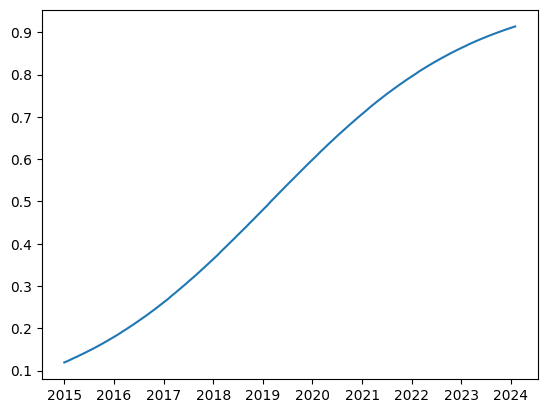

In [334]:
plt.plot(x, y)

$$y_i + y_i * 0.01 * \sin (30 * (i - 2))$$

In [335]:
# add sinusoidal variation
y = [y[idx] + y[idx] * .1 * np.sin((idx - 2) * (360 / 12) * (np.pi / 180)) for idx in range(len(y))]
y = [int(500 * val) for val in y]

In [336]:
df = pd.DataFrame({'ds': x, 'y': y})

In [337]:
df.head()

,ds,y
0,2015-01-01,54
1,2015-02-01,58
2,2015-03-01,63
3,2015-04-01,69
4,2015-05-01,74


In [338]:
# 성장을 선형으로 하겠다. yearly_seasonality => sin, cos 갯수
# n_changepoints=1 80% 구간에서 변경점을 찾겠다
model = Prophet(growth='linear',
                yearly_seasonality=3,
                seasonality_mode='multiplicative',
                n_changepoints=1)
model.fit(df)
future = model.make_future_dataframe(periods=12*10, freq='MS')
forecast = model.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


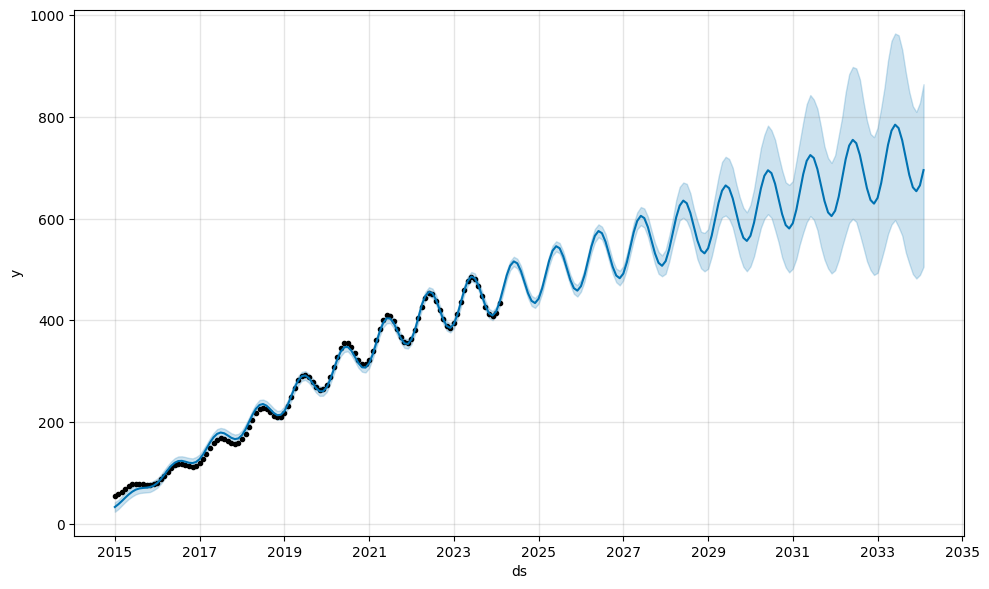

In [339]:
fig = model.plot(forecast)
plt.show()

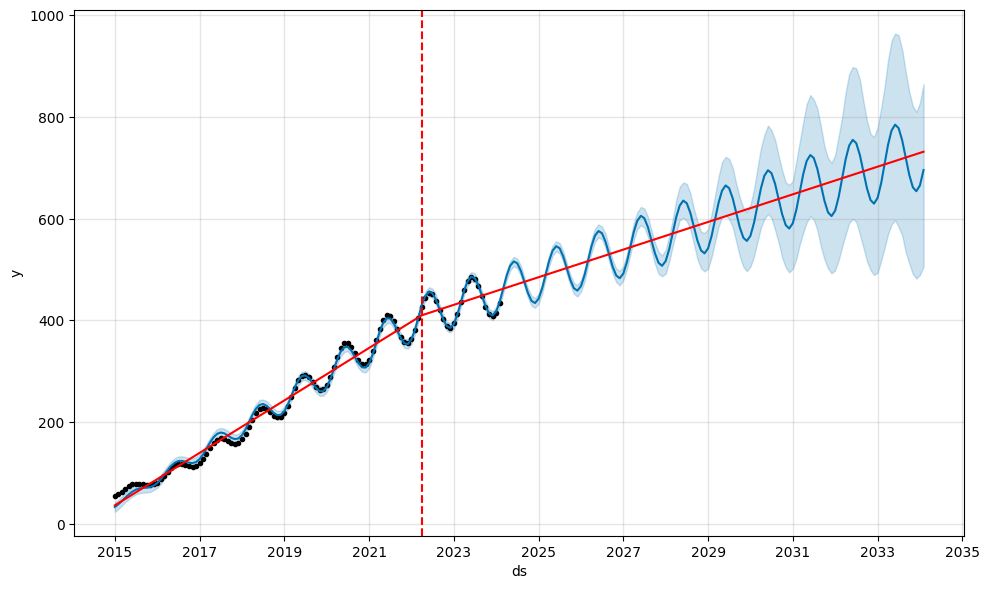

In [340]:
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast)
plt.show()

### Logistic growth

In [341]:
df['cap'] = 500

In [342]:
df

,ds,y,cap
0,2015-01-01,54,500
1,2015-02-01,58,500
2,2015-03-01,63,500
3,2015-04-01,69,500
4,2015-05-01,74,500
...,...,...,...
105,2023-10-01,427,500
106,2023-11-01,412,500
107,2023-12-01,408,500
108,2024-01-01,415,500


In [343]:
model = Prophet(growth='logistic', yearly_seasonality=3, seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=12*10, freq='MS')

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [344]:
future

,ds
0,2015-01-01
1,2015-02-01
2,2015-03-01
3,2015-04-01
4,2015-05-01
...,...
225,2033-10-01
226,2033-11-01
227,2033-12-01
228,2034-01-01


In [345]:
future['cap'] = 500

In [346]:
future

,ds,cap
0,2015-01-01,500
1,2015-02-01,500
2,2015-03-01,500
3,2015-04-01,500
4,2015-05-01,500
...,...,...
225,2033-10-01,500
226,2033-11-01,500
227,2033-12-01,500
228,2034-01-01,500


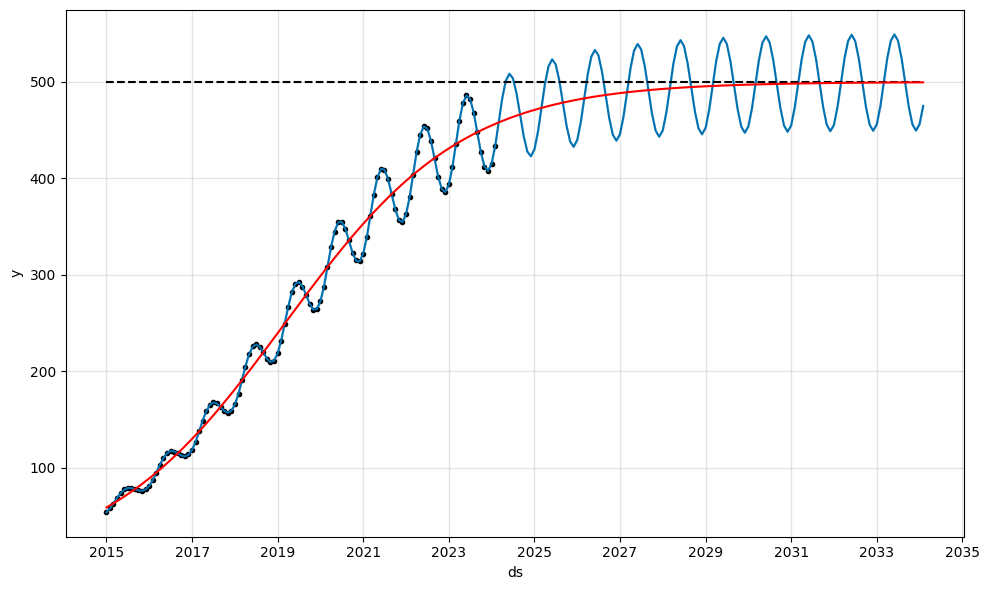

In [347]:
forecast = model.predict(future)
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast, cp_linestyle='')
plt.show()

In [348]:
def set_cap(row, df):
    if row.year < 2027:
        return 500
    else:
        pop_2027 = 500
        idx_2027 = df[df['ds'].dt.year == 2027].index[0] # 2027년도의 첫번째 인덱스
        idx_date = df[df['ds'] == row].index[0] # 현재 인덱스
    return pop_2027 + 2 * (idx_date - idx_2027)

In [349]:
model = Prophet(growth='logistic', yearly_seasonality=3, seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=12*10, freq='MS')
future['cap'] = future['ds'].apply(set_cap, args=(future,))

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [350]:
def col_sum(x, a, b):
    return a*x + b

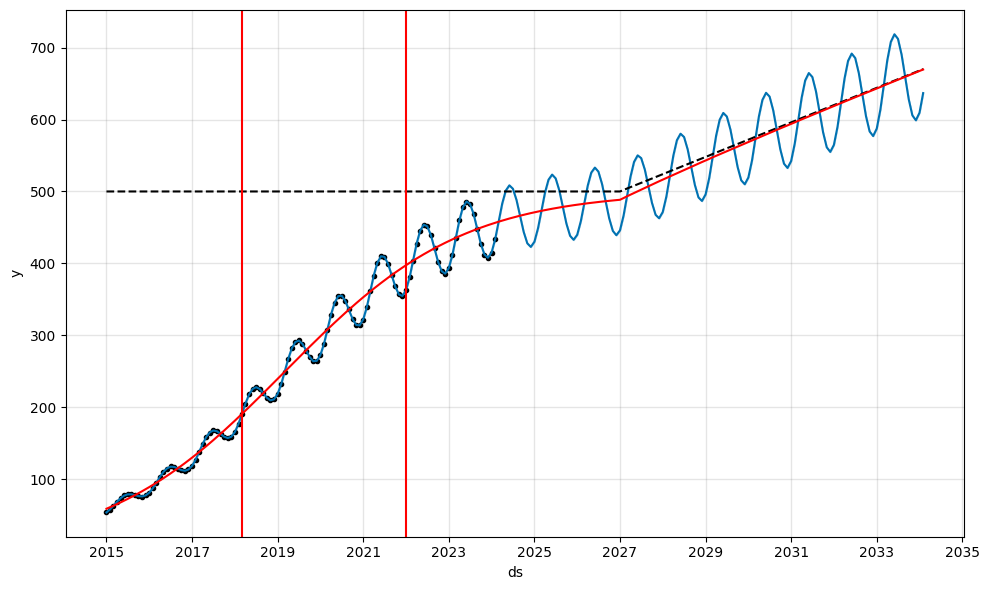

In [351]:
forecast = model.predict(future)
fig = model.plot(forecast)
add_changepoints_to_plot(fig.gca(), model, forecast, cp_linestyle='-')
plt.show()

## 2. s(t) : 계절성

계절성은 푸리에 급수로 모델링한다.

$$
s(t) = \sum_{n=1}^{N} (a_n cos(\frac{2\pi nt}{P}) + b_n sin(\frac{2\pi nt}{P}))
$$

N: 푸리에 차수

P: 주기(연도별 데이터 365.25, 주간별 데이터 7)
<br>
<br>
## 3. 공유일 효과
$$
h(t) = Z(t) \boldsymbol{\kappa}
\\ \ \\
Z(t) = [1 (t \in D_1) , \cdots, 1 ( t \in D_L)]
\\ \ \\
$$

z(T): 공휴일 1로 표시되고, 나머지는 0으로 표시되는 행렬

K: 공휴일 효과 계수 벡터

```
설정: lower_window=2, upper_window=1

날짜:    9/14 9/15 9/16 9/17 9/18
윈도우:  D_-2 D_-1 D_0 D_+1
```

In [352]:
!ls ./drive/MyDrive/data/Air*.csv

./drive/MyDrive/data/AirPassengers.csv


In [353]:
df = pd.read_csv('./drive/MyDrive/data/AirPassengers.csv')

In [354]:
df

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [355]:
df['Month'] = pd.to_datetime(df['Month'])

In [356]:
df.columns = ['ds', 'y']

In [357]:
df

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [358]:
df.tail()

,ds,y
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390
143,1960-12-01,432


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


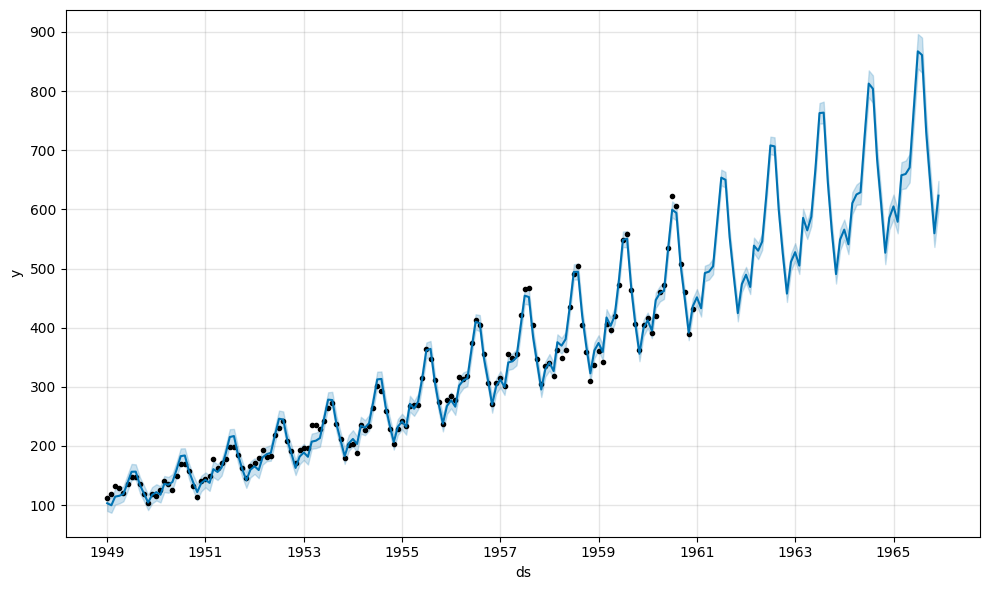

In [359]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=12*5, freq='MS')
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()

In [360]:
!ls ./drive/MyDrive/data/div*

./drive/MyDrive/data/divvy_hourly.csv


In [361]:
df = pd.read_csv('./drive/MyDrive/data/divvy_hourly.csv')

In [362]:
df

,date,rides
0,1/1/2014 1:00,1
1,1/1/2014 2:00,9
2,1/1/2014 3:00,4
3,1/1/2014 4:00,1
4,1/1/2014 7:00,2
...,...,...
34711,12/31/2017 20:00,10
34712,12/31/2017 21:00,9
34713,12/31/2017 22:00,3
34714,12/31/2017 23:00,8


In [363]:
df['date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

In [364]:
df.head()

,ds,y
0,2014-01-01 01:00:00,1
1,2014-01-01 02:00:00,9
2,2014-01-01 03:00:00,4
3,2014-01-01 04:00:00,1
4,2014-01-01 07:00:00,2


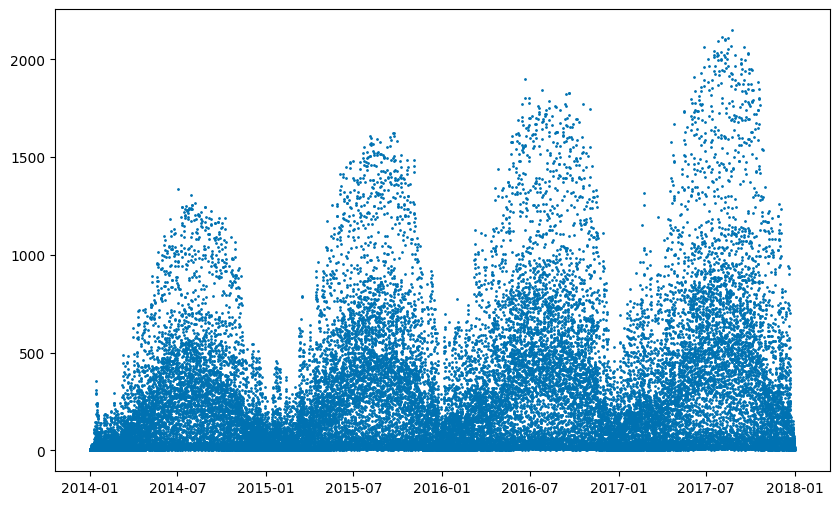

In [365]:
plt.figure(figsize=(10, 6))
plt.scatter(x=df['ds'], y=df['y'], s=1, c='#0072B2')
plt.show()

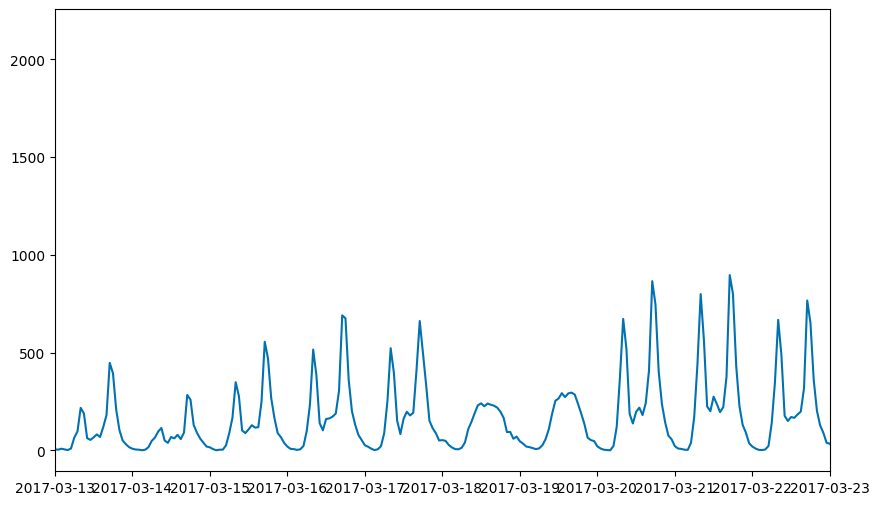

In [366]:
plt.figure(figsize=(10, 6))
plt.plot(df['ds'], df['y'], c='#0072B2')
plt.xlim(pd.to_datetime(['2017-03-13', '2017-03-23']))
plt.show()

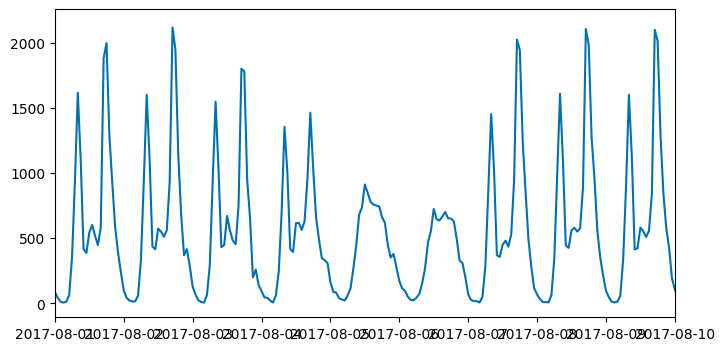

In [367]:
plt.figure(figsize=(8, 4))
plt.plot(df['ds'], df['y'], c='#0072B2')
plt.xlim(pd.to_datetime(['2017-08-01', '2017-08-10']))
plt.show()

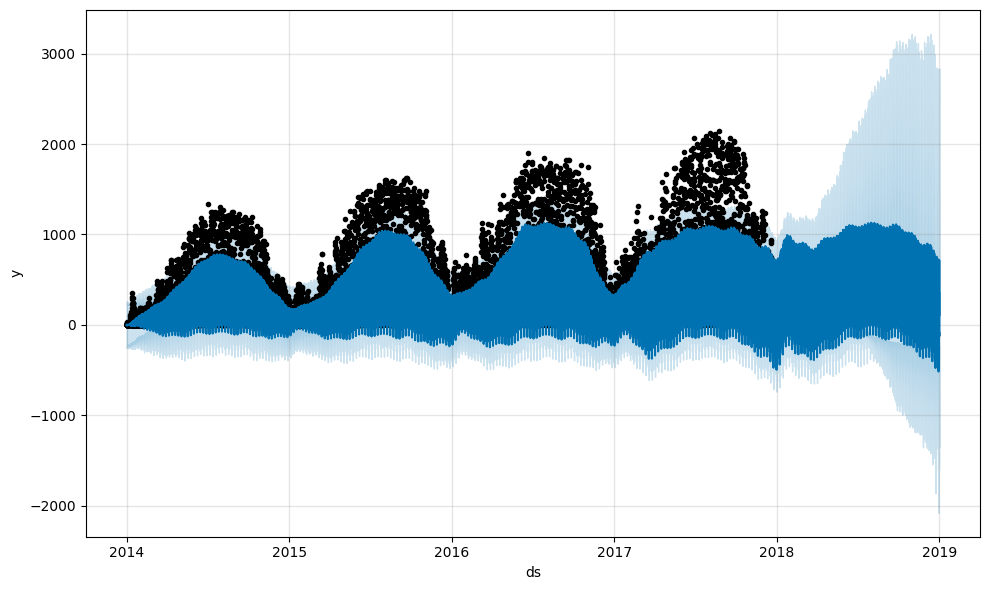

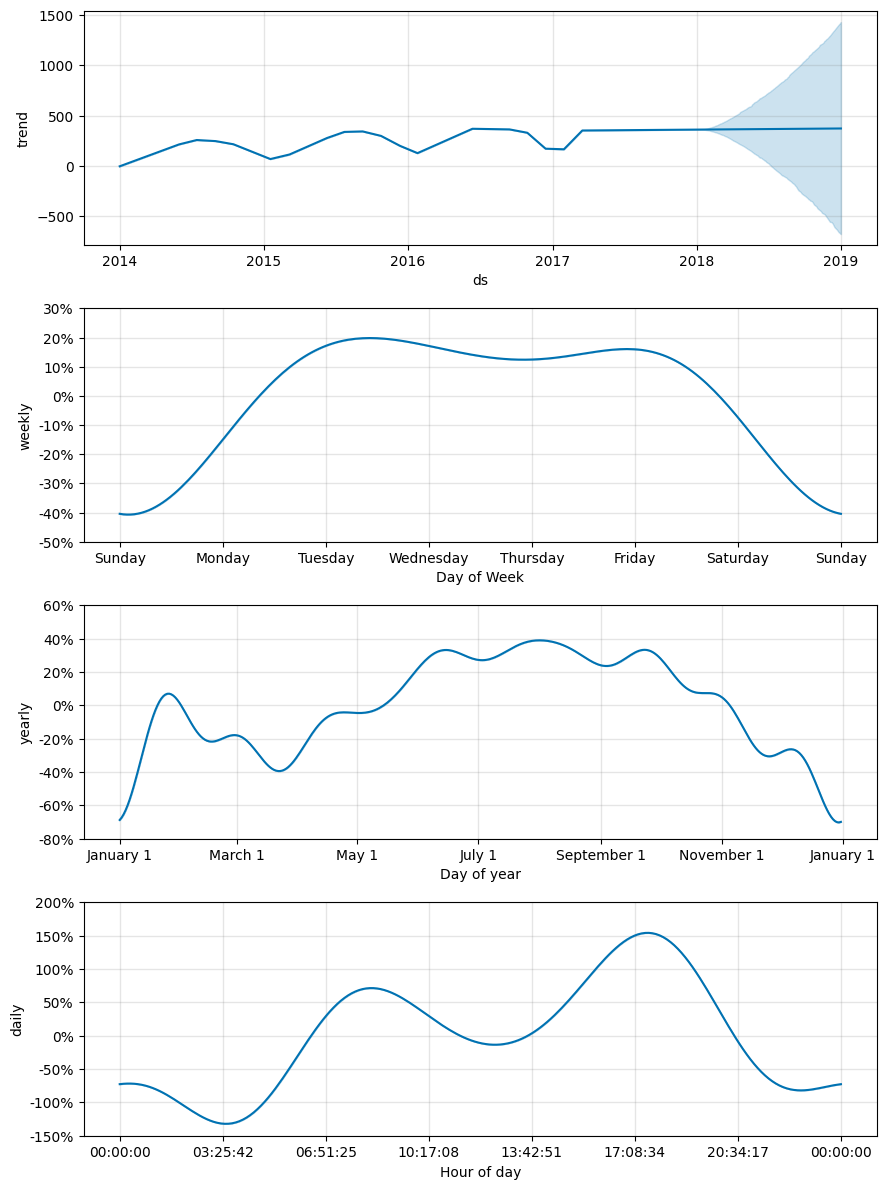

In [368]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=365*24, freq='h')
forecast = model.predict(future)
fig = model.plot(forecast)
fig2 = model.plot_components(forecast)
plt.show()

In [369]:
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

# 교차 검증 구간 설정

- Initial: 첫 훈련 기간 설정(730 days)
    - 1981.01.01 부터 1983.02.01까지

- Cutoff: period 매개변수에 지정 (180 days)
    - cutoff가 자동으로 변할 수 있게 period로 정한다.
    - 첫번째 cutoff는 1983.02.02이고 두번째 cutoff는 180일을 더해 1983.07.31 이 될것이다.

- Horizon: 예측 기간 (365 days)
- 대체적으로, period = Horizon / 2, initial = 3

  \* Horizon 정도로 한다

In [370]:
df_cv = cross_validation(model, horizon='365 days')

INFO:prophet:Making 1 forecasts with cutoffs between 2017-01-01 00:00:00 and 2017-01-01 00:00:00


  0%|          | 0/1 [00:00<?, ?it/s]

In [371]:
df_cv

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2017-01-01 01:00:00,-170.326831,-384.440262,32.225745,32,2017-01-01
1,2017-01-01 02:00:00,-224.729966,-444.113244,-18.685703,39,2017-01-01
2,2017-01-01 03:00:00,-283.526158,-495.632350,-76.334789,26,2017-01-01
3,2017-01-01 04:00:00,-284.916829,-497.500399,-64.361981,9,2017-01-01
4,2017-01-01 05:00:00,-198.519524,-419.717632,13.009781,3,2017-01-01
...,...,...,...,...,...,...
8732,2017-12-31 20:00:00,-76.870637,-648.185446,553.769350,10,2017-01-01
8733,2017-12-31 21:00:00,19.490303,-249.811872,262.230037,9,2017-01-01
8734,2017-12-31 22:00:00,73.616416,-552.066308,613.705017,3,2017-01-01
8735,2017-12-31 23:00:00,79.589279,-588.962623,649.209532,8,2017-01-01


In [372]:
df_p = performance_metrics(df_cv, rolling_window=0)

In [373]:
df_p

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,0 days 01:00:00,40936.146395,202.326831,202.326831,6.322713,6.322713,2.000000,1.0
1,0 days 02:00:00,69553.494978,263.729966,263.729966,6.762307,6.762307,2.000000,0.0
2,0 days 03:00:00,95806.442519,309.526158,309.526158,11.904852,11.904852,2.000000,0.0
3,0 days 04:00:00,86387.102205,293.916829,293.916829,32.657425,32.657425,2.000000,0.0
4,0 days 05:00:00,40610.118694,201.519524,201.519524,67.173175,67.173175,2.000000,1.0
...,...,...,...,...,...,...,...,...
8732,364 days 20:00:00,7546.507512,86.870637,86.870637,8.687064,8.687064,2.000000,1.0
8733,364 days 21:00:00,110.046452,10.490303,10.490303,1.165589,1.165589,0.736412,1.0
8734,364 days 22:00:00,4986.678225,70.616416,70.616416,23.538805,23.538805,1.843376,1.0
8735,364 days 23:00:00,5125.024903,71.589279,71.589279,8.948660,8.948660,1.634658,1.0


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


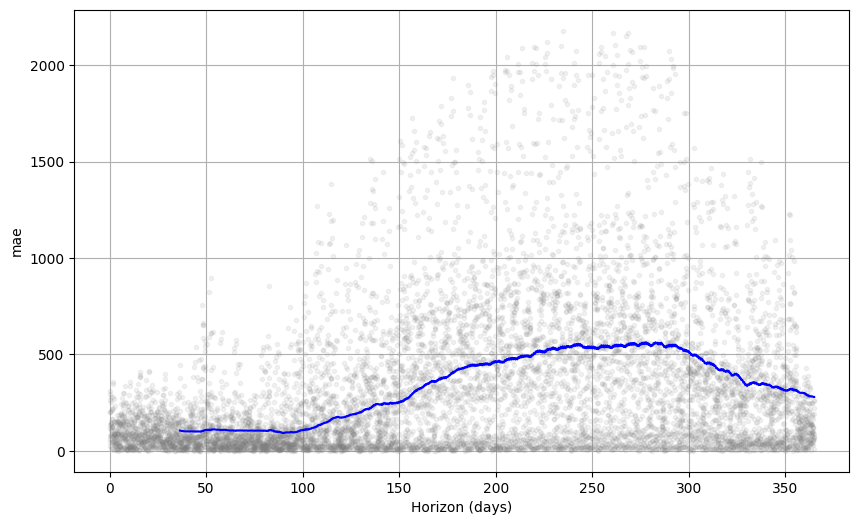

In [374]:
plot_cross_validation_metric(df_cv, metric='mae');
plt.show()

# 규칙적인 누락 구간을 가진 데이터

In [375]:
df = df[(df['ds'].dt.hour >= 8) & (df['ds'].dt.hour < 18)]

In [376]:
df

,ds,y
5,2014-01-01 08:00:00,7
6,2014-01-01 09:00:00,2
7,2014-01-01 10:00:00,4
8,2014-01-01 11:00:00,7
9,2014-01-01 12:00:00,9
...,...,...
34704,2017-12-31 13:00:00,49
34705,2017-12-31 14:00:00,62
34706,2017-12-31 15:00:00,72
34707,2017-12-31 16:00:00,55


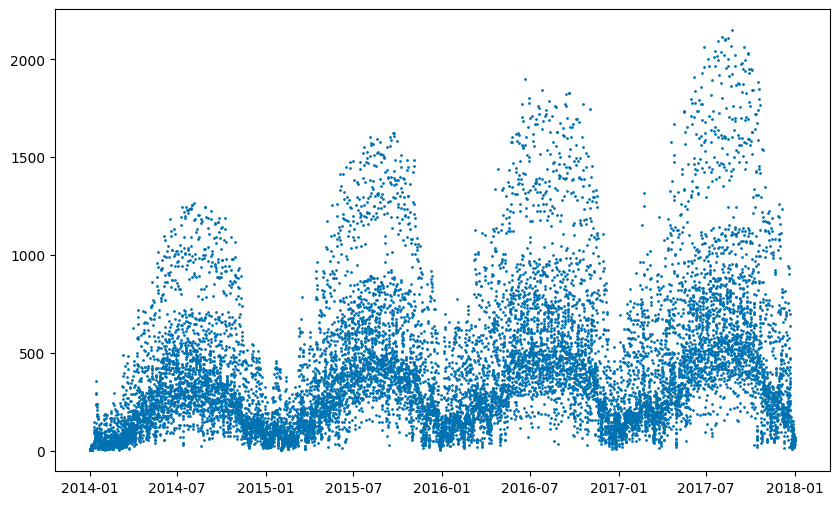

In [377]:
plt.figure(figsize=(10, 6))
plt.scatter(x=df['ds'], y=df['y'], s=1, c='#0072B2')
plt.show()

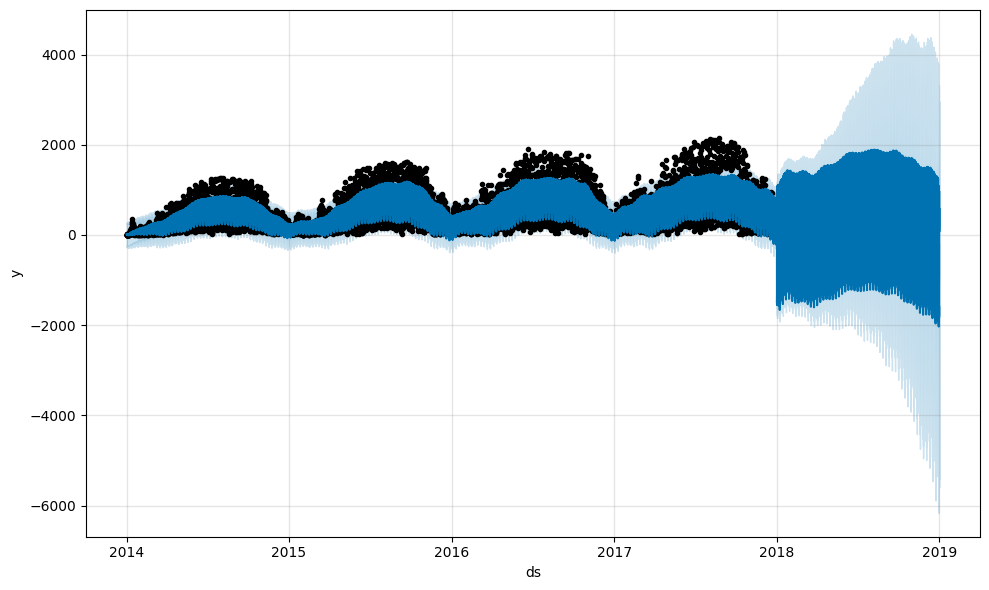

In [378]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=365*24, freq='h')
forecast = model.predict(future)
model.plot(forecast)
plt.show()

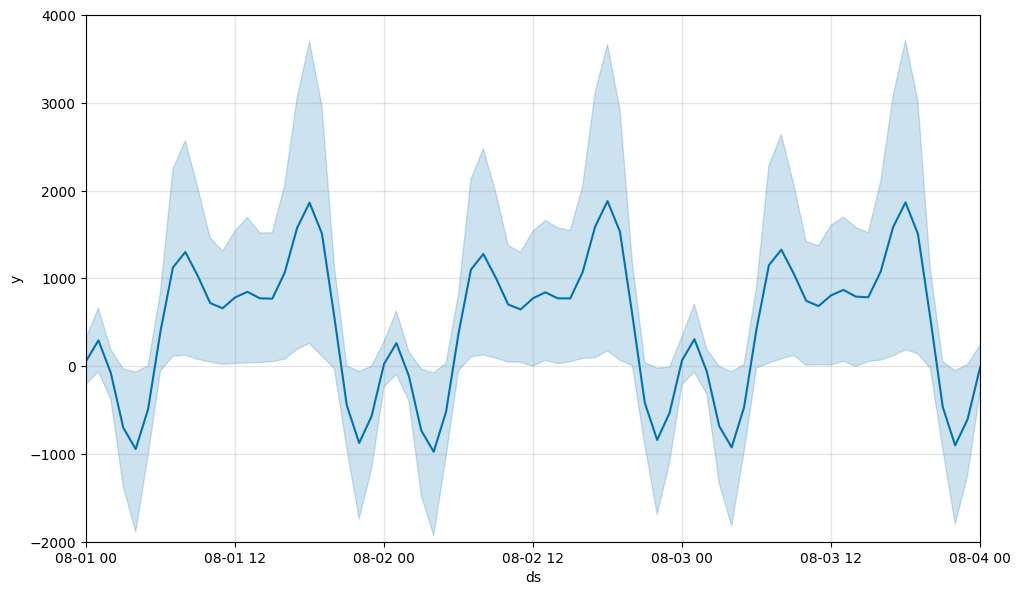

In [379]:
fig = model.plot(forecast)
plt.xlim(pd.to_datetime(['2018-08-01', '2018-08-04']))
plt.ylim(-2000, 4000)
plt.show()

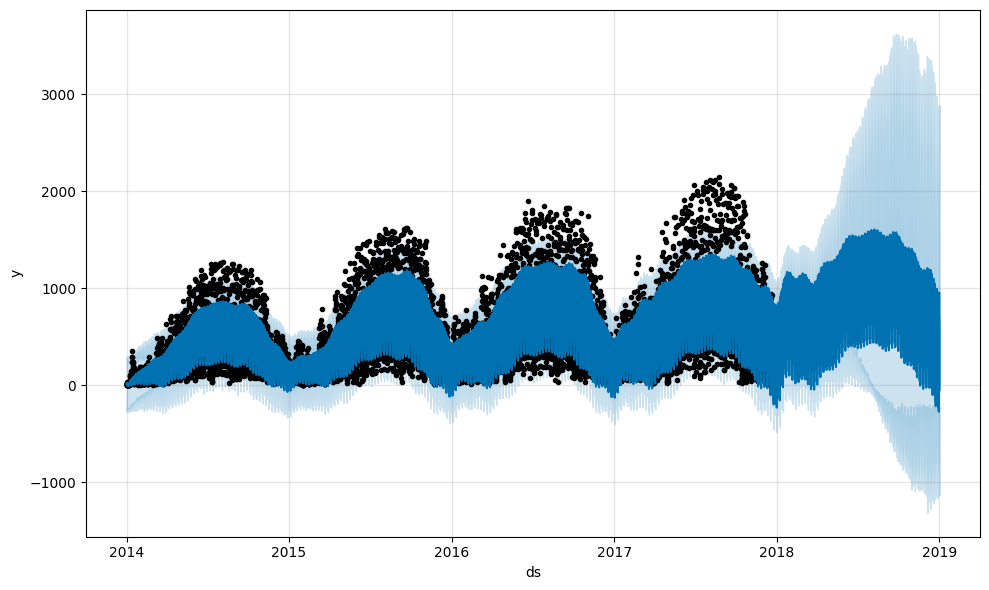

In [380]:
future2 = future[(future['ds'].dt.hour >= 8) & (future['ds'].dt.hour < 18)]
forecast2 = model.predict(future2)
fig = model.plot(forecast2)
plt.show()

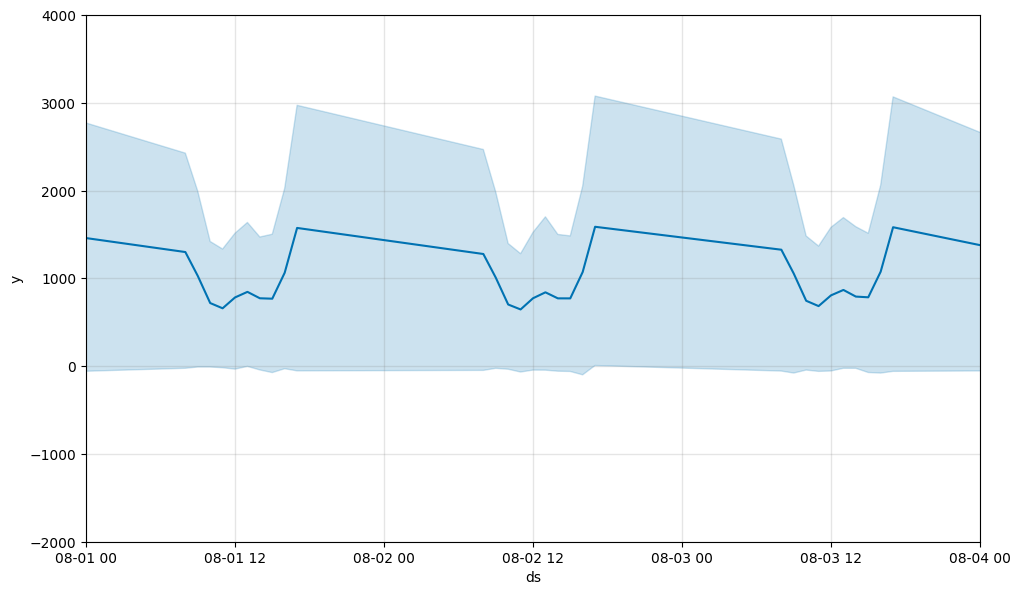

In [381]:
fig = model.plot(forecast2)
plt.xlim(pd.to_datetime(['2018-08-01', '2018-08-04']))
plt.ylim(-2000, 4000)
plt.show()

In [382]:
from prophet.plot import plot_seasonality

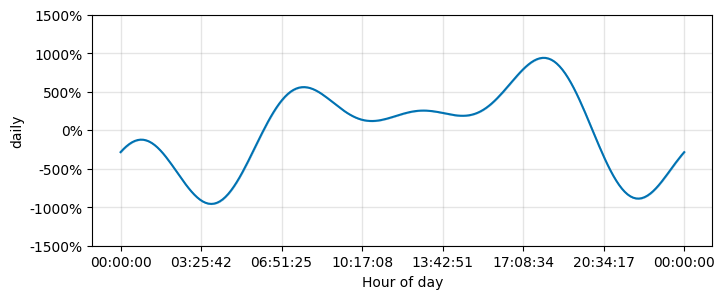

In [383]:
plot_seasonality(model, 'daily', figsize=(8, 3))
plt.show()

# 계절성

In [384]:
df = pd.read_csv('./drive/MyDrive/data/AirPassengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.columns = ['ds', 'y']

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


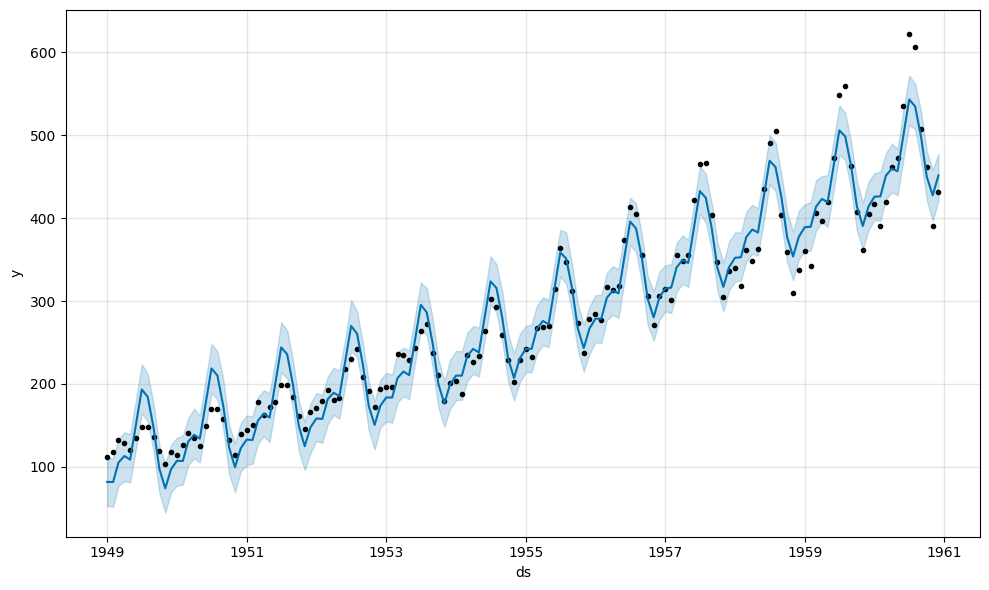

In [385]:
model_a = Prophet(seasonality_mode='additive', yearly_seasonality=4)
model_a.fit(df)
forecast_a = model_a.predict()
fig_a = model_a.plot(forecast_a)
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


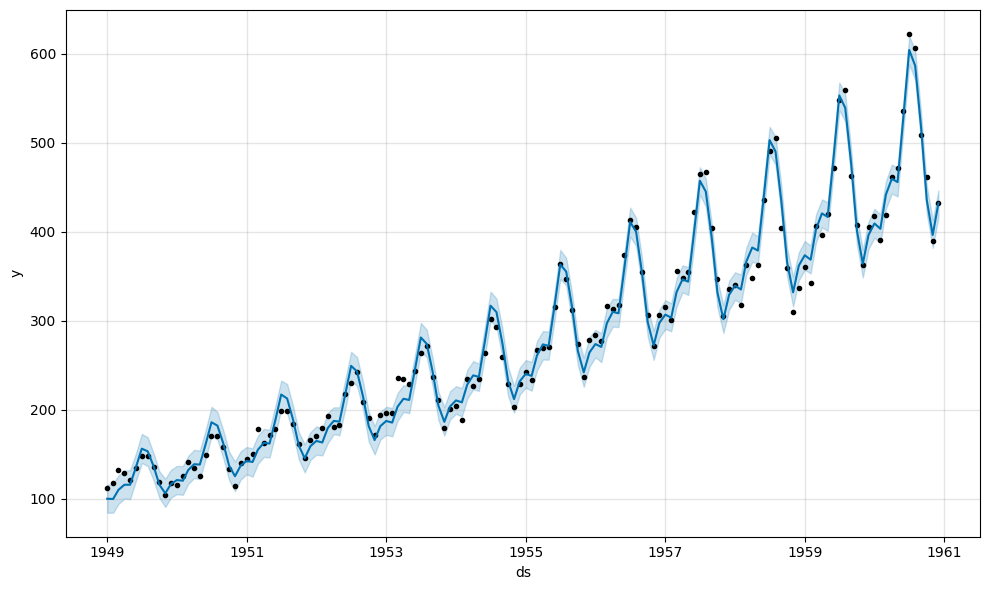

In [386]:
model_m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=4)
model_m.fit(df)
forecast_m = model_m.predict()
fig_m = model_m.plot(forecast_m)
plt.show()

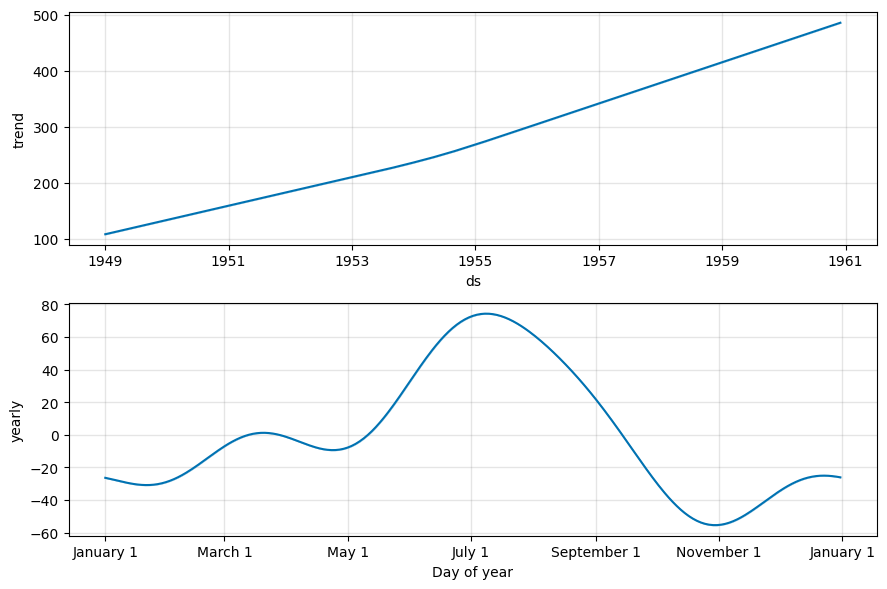

In [387]:
fig_a2 = model_a.plot_components(forecast_a)
plt.show()

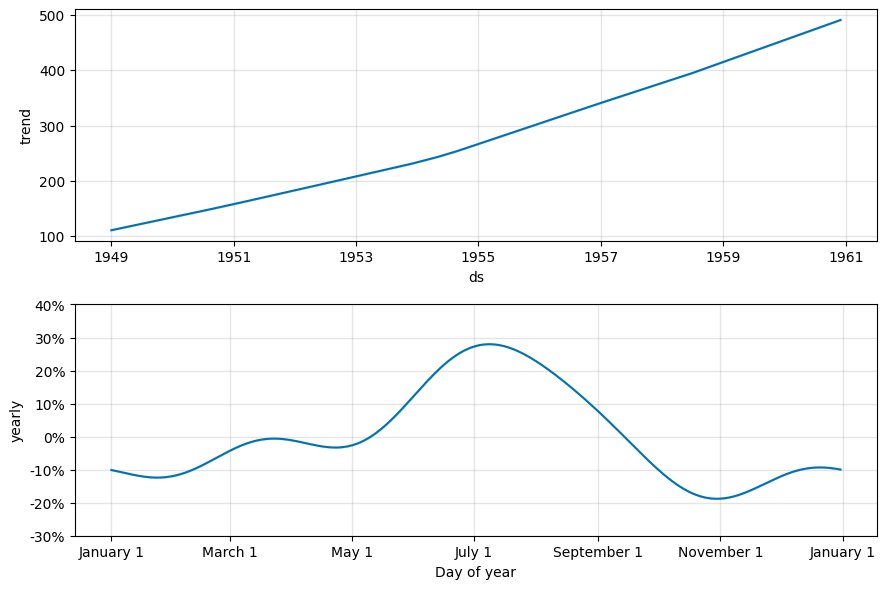

In [388]:
fig_m2 = model_m.plot_components(forecast_m)
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


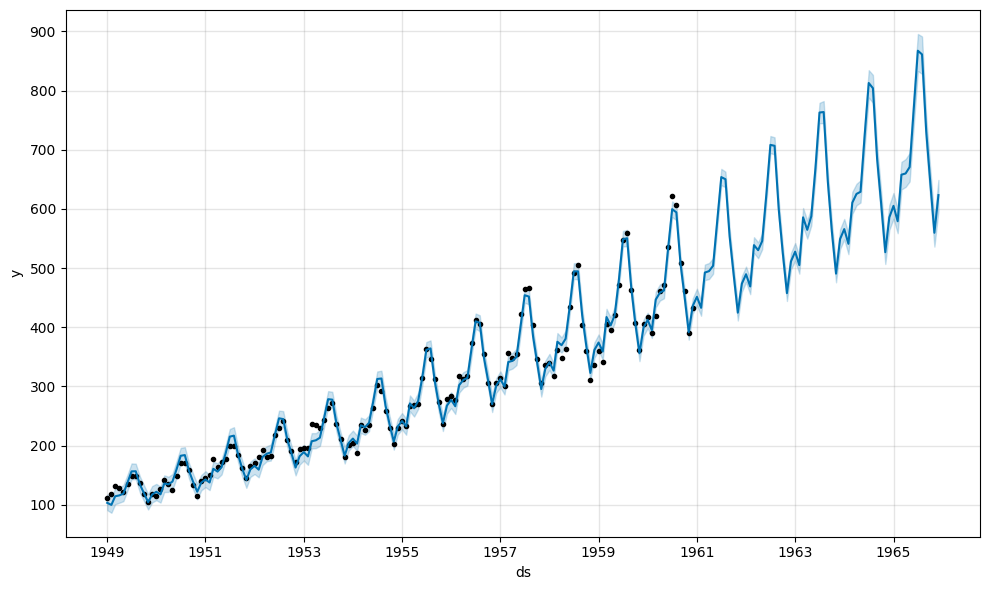

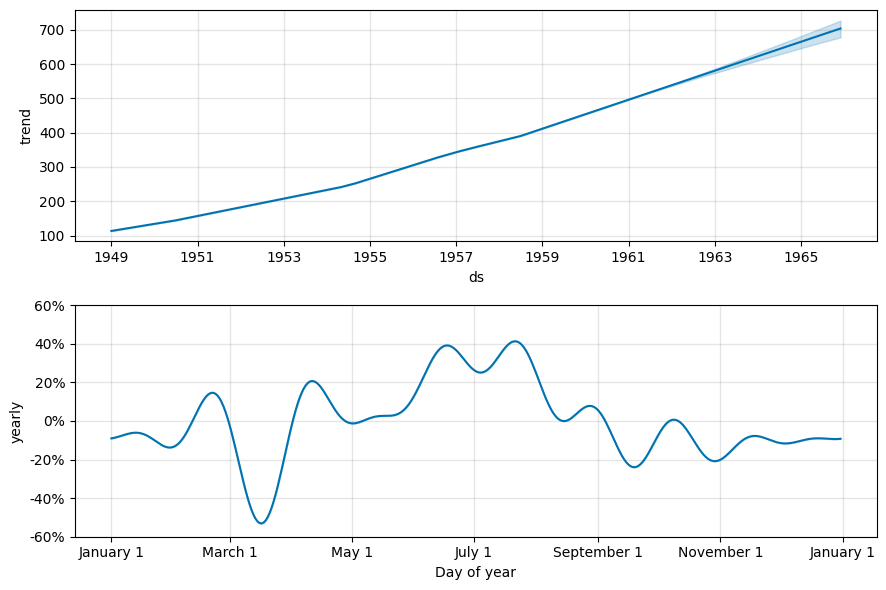

In [390]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future_df = model.make_future_dataframe(periods=12*5, freq='MS')
forecast = model.predict(future_df)
fig = model.plot(forecast)
fig2s = model.plot_components(forecast)
plt.show()

In [402]:
df = pd.read_csv('./drive/MyDrive/data/divvy_daily.csv')

In [403]:
df.head()

,date,rides,temperature,weather
0,1/1/2014,95,19.483158,rain or snow
1,1/2/2014,111,16.833333,rain or snow
2,1/3/2014,6,-5.633333,clear
3,1/4/2014,181,30.007735,rain or snow
4,1/5/2014,32,16.756250,rain or snow


In [404]:
df = df[['date', 'rides']]
df.loc[:, 'date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

In [405]:
df.head()

,ds,y
0,2014-01-01 00:00:00,95
1,2014-01-02 00:00:00,111
2,2014-01-03 00:00:00,6
3,2014-01-04 00:00:00,181
4,2014-01-05 00:00:00,32


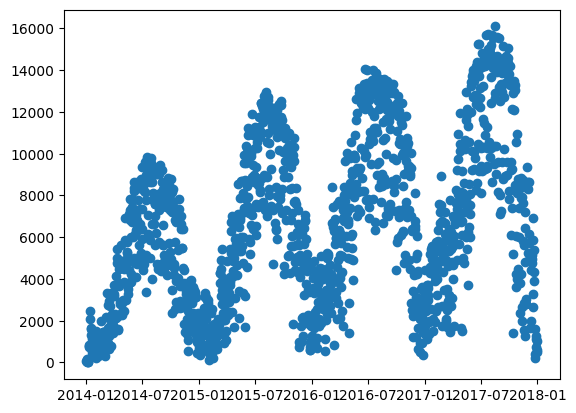

In [406]:
plt.scatter(x=df['ds'], y=df['y'])

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


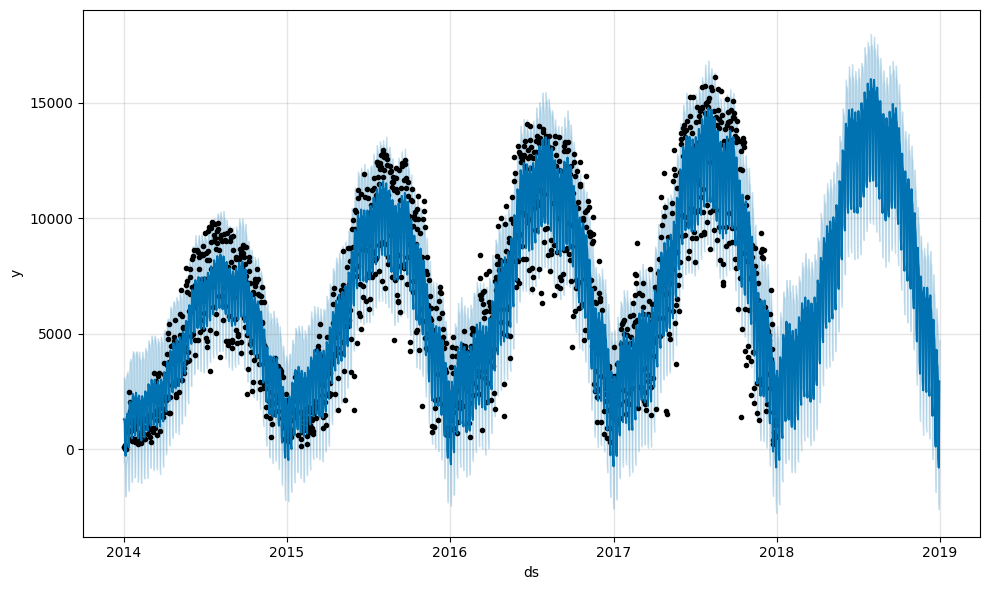

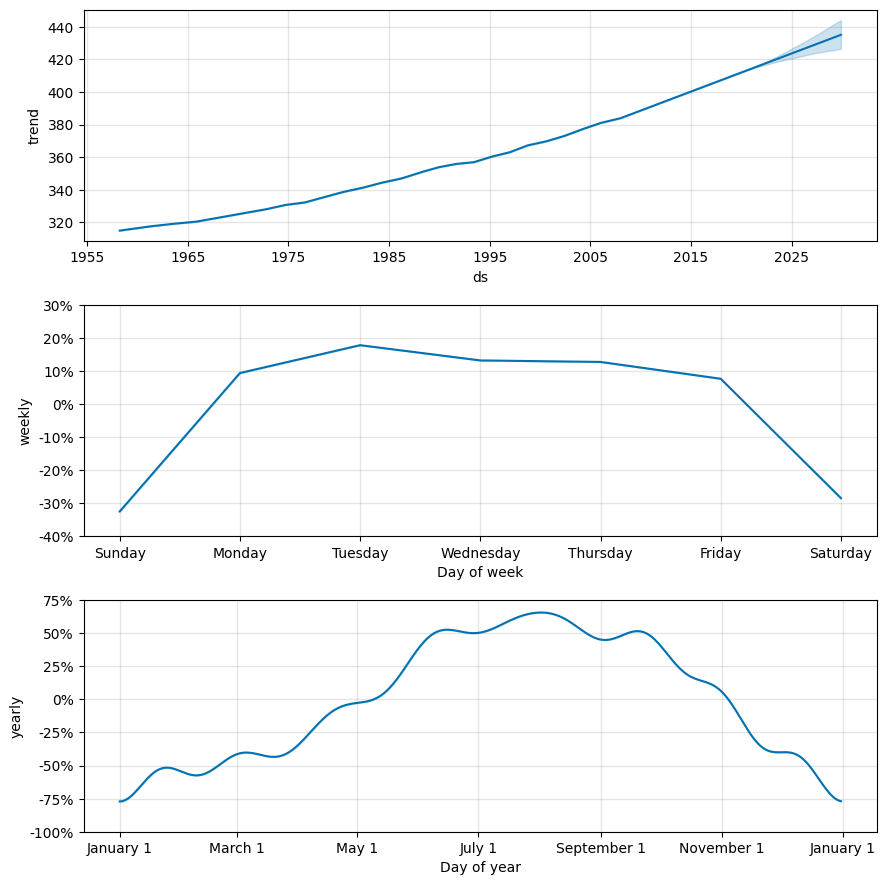

In [408]:
model = Prophet(seasonality_mode='multiplicative')
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()
fig2 = model.plot_components(forcast)
plt.show()

In [409]:
model.__dict__

{'growth': 'linear',
 'changepoints': 47     2014-02-19
 93     2014-04-06
 140    2014-05-23
 186    2014-07-08
 233    2014-08-24
 280    2014-10-10
 326    2014-11-26
 373    2015-01-12
 419    2015-02-27
 466    2015-04-15
 513    2015-06-01
 559    2015-07-17
 606    2015-09-02
 652    2015-10-18
 699    2015-12-04
 746    2016-01-20
 792    2016-03-06
 839    2016-04-22
 885    2016-06-07
 932    2016-07-24
 979    2016-09-09
 1025   2016-10-25
 1072   2016-12-11
 1118   2017-01-26
 1165   2017-03-14
 Name: ds, dtype: datetime64[ns],
 'n_changepoints': 25,
 'specified_changepoints': False,
 'changepoint_range': 0.8,
 'yearly_seasonality': 'auto',
 'weekly_seasonality': 'auto',
 'daily_seasonality': 'auto',
 'holidays': None,
 'seasonality_mode': 'multiplicative',
 'holidays_mode': 'multiplicative',
 'seasonality_prior_scale': 10.0,
 'changepoint_prior_scale': 0.05,
 'holidays_prior_scale': 10.0,
 'mcmc_samples': 0,
 'interval_width': 0.8,
 'uncertainty_samples': 1000,
 'scaling':

## Prior scale
: 규제하는 역할
```
작을수록 : 단순한 모델 --> 과소적합

클 수록 : 복잡한 모델 --> 과대적합
```

In [411]:
params = {
    'growth': model.growth,
    'changepoint_prior_scale': model.changepoint_prior_scale,
    'seasonality_prior_scale': model.seasonality_prior_scale,
    'holidays_prior_scale': model.holidays_prior_scale,
    'seasonality_mode': model.seasonality_mode,
    'yearly_seasonality': model.yearly_seasonality,
    'weekly_seasonality': model.weekly_seasonality,
    'daily_seasonality': model.daily_seasonality,
    'n_changepoints': model.n_changepoints,
}

In [413]:
model.params

OrderedDict([('lp__', array([[2758.5364]])),
             ('k', array([[0.41943952]])),
             ('m', array([[0.22381061]])),
             ('delta',
              array([[-2.2713007e-07, -6.7719718e-08, -2.6493268e-06, -7.0770718e-07,
                      -4.1952326e-08,  1.0299926e-08,  3.6320174e-08,  1.5844452e-05,
                       2.4872275e-02,  1.4241071e-07,  7.0825284e-08, -6.3577629e-08,
                      -1.6921622e-02, -9.8689933e-02, -8.6041600e-02, -4.8003653e-02,
                      -2.1533609e-02, -1.7284104e-03, -6.4018397e-05, -7.2963095e-09,
                      -3.5680904e-08,  1.7338202e-08,  1.5540251e-08, -2.3506138e-07,
                      -7.9567637e-08]])),
             ('sigma_obs', array([[0.09107761]])),
             ('beta',
              array([[-0.28800771, -0.56717968,  0.02893195, -0.03489747,  0.0480764 ,
                      -0.04531709,  0.00801441, -0.00603673, -0.00105159, -0.0087859 ,
                      -0.01513532, -0.031

In [414]:
model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=4)
model.fit(df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [415]:
from prophet.plot import plot_yearly

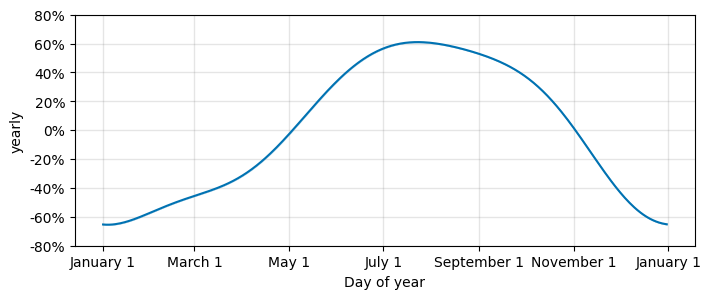

In [416]:
fig3 = plot_yearly(model, figsize=(8, 3))
plt.show()

In [417]:
model.param

OrderedDict([('lp__', array([[2716.3404]])),
             ('k', array([[0.41375629]])),
             ('m', array([[0.22517545]])),
             ('delta',
              array([[ 2.7959154e-08, -9.9740120e-09, -8.3914667e-10, -1.4743056e-07,
                       1.2554640e-07,  2.0716706e-08,  1.4644690e-07,  2.3794391e-05,
                       2.9022634e-02,  3.2689800e-06,  1.1385242e-08, -9.4949362e-08,
                      -1.0306626e-02, -9.1808228e-02, -8.3505722e-02, -5.4902124e-02,
                      -3.4372421e-02, -9.5517801e-05, -8.2280380e-08, -6.9464165e-10,
                      -1.8208652e-08,  5.8047532e-09,  3.3108928e-08,  2.1158171e-08,
                       1.9948423e-08]])),
             ('sigma_obs', array([[0.09354344]])),
             ('beta',
              array([[-0.28864037, -0.56714305,  0.02840766, -0.03478341,  0.04723076,
                      -0.04510412,  0.00652693, -0.00560826, -0.19343026,  0.13966606,
                       0.13557306,  0.009

연간 계절성 : 차수 10

주간 계절성 : 차수 3

하루보다 짧은 주기의 데이터 : 차수 4

연간 데이터 : ds 열에 최소 2년치 데이터

날짜 간격 7일 미만 데이터: 2주 이상의 데이터

시간 간격 1일 미만 데이터: 2일 이상의 데이터